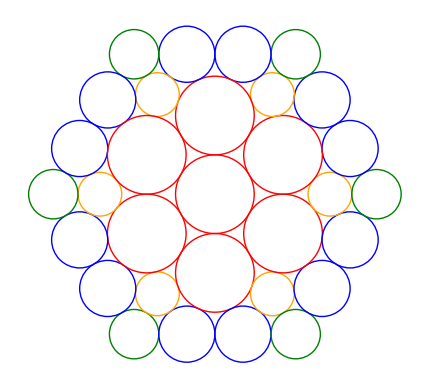

In [ ]:
import math
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

R=0.71330771379623650488484583794241440973401744637287
S=0.62745811971994135794576801322481626845749975934269
T=0.55622734861966355128201346655727006506472697742872

nodes={1:'S',2:'R',3:'R',4:'S',5:'R',6:'R',7:'S',8:'R',9:'R',10:'S',
       11:'R',12:'R',13:'S',14:'R',15:'R',16:'S',17:'R',18:'R',
       19:'T',20:'T',21:'T',22:'T',23:'T',24:'T',
       25:'1',26:'1',27:'1',28:'1',29:'1',30:'1',31:'1'}

adj={1:[2],2:[3],3:[4],4:[5],5:[6],6:[7],7:[8],8:[9],9:[10],10:[11],
     11:[12],12:[13],13:[14],14:[15],15:[16],16:[17],17:[18],18:[1],
     19:[18,1,2],20:[3,4,5],21:[6,7,8],22:[9,10,11],23:[12,13,14],24:[15,16,17],
     25:[24,17,18,19,26],26:[19,2,3,20,27],27:[20,5,6,21,28],
     28:[21,8,9,22,29],29:[22,11,12,23,30],30:[23,14,15,24,25],
     31:[25,26,27,28,29,30]}

for x in range(1,32):
    for y in adj[x]:
        if x not in adj[y]:
            adj[y].append(x)

rmap={'1':1.0,'R':R,'S':S,'T':T}
pos={}
pos[1]=(0.0,0.0)
pos[2]=(rmap[nodes[1]]+rmap[nodes[2]],0.0)

def intersections(c1,r1,c2,r2):
    x1,y1=c1; x2,y2=c2
    dx,dy=x2-x1,y2-y1
    d=math.hypot(dx,dy)
    a=(r1*r1-r2*r2+d*d)/(2*d)
    h=math.sqrt(max(r1*r1-a*a,0.0))
    xm=x1+a*dx/d; ym=y1+a*dy/d
    rx,ry= -dy*(h/d), dx*(h/d)
    return [(xm+rx,ym+ry),(xm-rx,ym-ry)]

tol=1e-6
while len(pos)<len(nodes):
    for i in nodes:
        if i in pos: continue
        neigh=[j for j in adj[i] if j in pos]
        if len(neigh)>=2:
            a,b=neigh[0],neigh[1]
            pa, pb = pos[a], pos[b]
            ra, rb = rmap[nodes[i]]+rmap[nodes[a]], rmap[nodes[i]]+rmap[nodes[b]]
            cands=intersections(pa,ra,pb,rb)
            for cx,cy in cands:
                ok=True
                for j,(jx,jy) in pos.items():
                    if j==a or j==b: continue
                    if math.hypot(cx-jx,cy-jy) < rmap[nodes[i]]+rmap[nodes[j]]-tol:
                        ok=False; break
                if ok:
                    pos[i]=(cx,cy)
                    break
            else:
                pos[i]=cands[0]
            break

color_map={1.0:'red',R:'blue',S:'green',T:'orange'}

fig,ax=plt.subplots()
for i,(x,y) in pos.items():
    r=rmap[nodes[i]]
    ax.add_patch(Circle((x,y),r,fill=False,edgecolor=color_map[r]))
ax.set_aspect('equal'); ax.autoscale(); plt.axis('off'); plt.show()

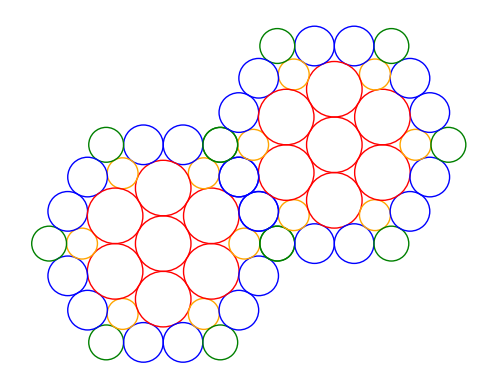

In [62]:
import math
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

R=0.71330771379623650488484583794241440973401744637287
S=0.62745811971994135794576801322481626845749975934269
T=0.55622734861966355128201346655727006506472697742872

nodes={1:'S',2:'R',3:'R',4:'S',5:'R',6:'R',7:'S',8:'R',9:'R',10:'S',
       11:'R',12:'R',13:'S',14:'R',15:'R',16:'S',17:'R',18:'R',
       19:'T',20:'T',21:'T',22:'T',23:'T',24:'T',
       25:'1',26:'1',27:'1',28:'1',29:'1',30:'1',31:'1'}

adj={1:[2],2:[3],3:[4],4:[5],5:[6],6:[7],7:[8],8:[9],9:[10],10:[11],
     11:[12],12:[13],13:[14],14:[15],15:[16],16:[17],17:[18],18:[1],
     19:[18,1,2],20:[3,4,5],21:[6,7,8],22:[9,10,11],23:[12,13,14],24:[15,16,17],
     25:[24,17,18,19,26],26:[19,2,3,20,27],27:[20,5,6,21,28],
     28:[21,8,9,22,29],29:[22,11,12,23,30],30:[23,14,15,24,25],
     31:[25,26,27,28,29,30]}

for x in range(1,32):
    for y in adj[x]:
        if x not in adj[y]:
            adj[y].append(x)

rmap={'1':1.0,'R':R,'S':S,'T':T}
pos={}
pos[1]=(0.0,0.0)
pos[2]=(rmap[nodes[1]]+rmap[nodes[2]],0.0)

def intersections(c1,r1,c2,r2):
    x1,y1=c1; x2,y2=c2
    dx,dy=x2-x1,y2-y1
    d=math.hypot(dx,dy)
    a=(r1*r1-r2*r2+d*d)/(2*d)
    h=math.sqrt(max(r1*r1-a*a,0.0))
    xm=x1+a*dx/d; ym=y1+a*dy/d
    rx,ry=-dy*(h/d),dx*(h/d)
    return [(xm+rx,ym+ry),(xm-rx,ym-ry)]

tol=1e-6
while len(pos)<len(nodes):
    for i in nodes:
        if i in pos: continue
        neigh=[j for j in adj[i] if j in pos]
        if len(neigh)>=2:
            a,b=neigh[0],neigh[1]
            pa,pb=pos[a],pos[b]
            ra=rmap[nodes[i]]+rmap[nodes[a]]
            rb=rmap[nodes[i]]+rmap[nodes[b]]
            cands=intersections(pa,ra,pb,rb)
            for cx,cy in cands:
                ok=True
                for j,(jx,jy) in pos.items():
                    if j in (a,b): continue
                    if math.hypot(cx-jx,cy-jy)<rmap[nodes[i]]+rmap[nodes[j]]-tol:
                        ok=False; break
                if ok:
                    pos[i]=(cx,cy)
                    break
            else:
                pos[i]=cands[0]
            break

dx,dy=pos[7][0]-pos[1][0],pos[7][1]-pos[1][1]
color_map={1.0:'red',R:'blue',S:'green',T:'orange'}

fig,ax=plt.subplots()
for i,(x,y) in pos.items():
    r=rmap[nodes[i]]
    ax.add_patch(Circle((x,y),r,fill=False,edgecolor=color_map[r]))
for i,(x,y) in pos.items():
    r=rmap[nodes[i]]
    ax.add_patch(Circle((x+dx,y+dy),r,fill=False,edgecolor=color_map[r]))
ax.set_aspect('equal'); ax.autoscale(); plt.axis('off'); plt.show()


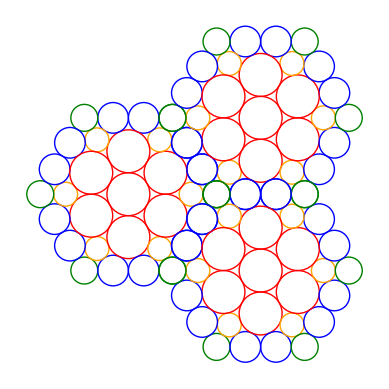

In [63]:
import math
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

R=0.71330771379623650488484583794241440973401744637287
S=0.62745811971994135794576801322481626845794576801322481626845749975934269
T=0.55622734861966355128201346655727006506472697742872

nodes={1:'S',2:'R',3:'R',4:'S',5:'R',6:'R',7:'S',8:'R',9:'R',10:'S',
       11:'R',12:'R',13:'S',14:'R',15:'R',16:'S',17:'R',18:'R',
       19:'T',20:'T',21:'T',22:'T',23:'T',24:'T',
       25:'1',26:'1',27:'1',28:'1',29:'1',30:'1',31:'1'}

adj={1:[2],2:[3],3:[4],4:[5],5:[6],6:[7],7:[8],8:[9],9:[10],10:[11],
     11:[12],12:[13],13:[14],14:[15],15:[16],16:[17],17:[18],18:[1],
     19:[18,1,2],20:[3,4,5],21:[6,7,8],22:[9,10,11],23:[12,13,14],24:[15,16,17],
     25:[24,17,18,19,26],26:[19,2,3,20,27],27:[20,5,6,21,28],
     28:[21,8,9,22,29],29:[22,11,12,23,30],30:[23,14,15,24,25],
     31:[25,26,27,28,29,30]}

for x in range(1,32):
    for y in adj[x]:
        if x not in adj[y]:
            adj[y].append(x)

rmap={'1':1.0,'R':R,'S':S,'T':T}
pos={}
pos[1]=(0.0,0.0)
pos[2]=(rmap[nodes[1]]+rmap[nodes[2]],0.0)

def intersections(c1,r1,c2,r2):
    x1,y1=c1; x2,y2=c2
    dx,dy=x2-x1,y2-y1
    d=math.hypot(dx,dy)
    a=(r1*r1-r2*r2+d*d)/(2*d)
    h=math.sqrt(max(r1*r1-a*a,0.0))
    xm=x1+a*dx/d; ym=y1+a*dy/d
    rx,ry=-dy*(h/d),dx*(h/d)
    return [(xm+rx,ym+ry),(xm-rx,ym-ry)]

tol=1e-6
while len(pos)<len(nodes):
    for i in nodes:
        if i in pos: continue
        neigh=[j for j in adj[i] if j in pos]
        if len(neigh)>=2:
            a,b=neigh[0],neigh[1]
            pa,pb=pos[a],pos[b]
            ra=rmap[nodes[i]]+rmap[nodes[a]]
            rb=rmap[nodes[i]]+rmap[nodes[b]]
            cands=intersections(pa,ra,pb,rb)
            for cx,cy in cands:
                ok=True
                for j,(jx,jy) in pos.items():
                    if j in (a,b): continue
                    if math.hypot(cx-jx,cy-jy)<rmap[nodes[i]]+rmap[nodes[j]]-tol:
                        ok=False; break
                if ok:
                    pos[i]=(cx,cy)
                    break
            else:
                pos[i]=cands[0]
            break

dx1,dy1=pos[7][0]-pos[1][0],pos[7][1]-pos[1][1]
dx2,dy2=pos[7][0]-pos[13][0],pos[7][1]-pos[13][1]
color_map={1.0:'red',R:'blue',S:'green',T:'orange'}

fig,ax=plt.subplots()
for i,(x,y) in pos.items():
    r=rmap[nodes[i]]
    ax.add_patch(Circle((x,y),r,fill=False,edgecolor=color_map[r]))
for i,(x,y) in pos.items():
    r=rmap[nodes[i]]
    ax.add_patch(Circle((x+dx1,y+dy1),r,fill=False,edgecolor=color_map[r]))
for i,(x,y) in pos.items():
    r=rmap[nodes[i]]
    ax.add_patch(Circle((x+dx2,y+dy2),r,fill=False,edgecolor=color_map[r]))
ax.set_aspect('equal')
ax.autoscale()
plt.axis('off')
plt.show()
